In [54]:
# Config
import os
import json
import geojson
import leafmap.leafmap as leafmap
import requests
from PIL import Image

# Basic
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Monitoring
from tqdm.notebook import tqdm

# IO
from os.path import join, exists, basename, dirname, splitext, expanduser
from glob import glob
from shapely.geometry import Point
from shapely import vectorized

import geopandas as gpd

# Parallel processing
from joblib import Parallel, delayed
import concurrent.futures as cf

import rioxarray as rxr

# Load environment variables
from dotenv import load_dotenv
load_dotenv()

True

In [55]:
import os
# for key in os.environ:
#     # print(key)

In [56]:
region = "vlm_data" # "uttar_pradesh", "delhi_airshed", "wb_small_airshed", "lucknow_airshed", "ahmedabad_10km_buffer", "bihar"
download_dir = "../raw_data"
quarter = "2024q1"
PLANET_API_KEY="PLAKea85382c048b4ba086c40e3823d83d11" #zeel
# Planet API Key PLAK728a0100ad5746d4ab8e06a617215030 # shataxi

# PLANET_API_KEY = os.getenv("PLANET_API_KEY")
print(PLANET_API_KEY)
assert PLANET_API_KEY is not None
# shape_path = f"../regions/shapes/{region}.geojson"
shape_path = f"/home/shataxi.dubey/shataxi_work/vlm_on_planet/lucknow_kilns.geojson"

print(shape_path)

shape_gdf = gpd.read_file(shape_path)
shape_gdf = shape_gdf.to_crs("EPSG:4326")
# shape_gdf=shape_gdf[]
# print()
print(shape_gdf.crs)
print(shape_gdf.tail()) 
print(shape_gdf.shape)

#Accessing the first row of the geodataframe
# print(shape_gdf.iloc[0])
# shape_gdf=shape_gdf.iloc[0]

PLAKea85382c048b4ba086c40e3823d83d11
/home/shataxi.dubey/shataxi_work/vlm_on_planet/lucknow_kilns.geojson
EPSG:4326
                                             geometry
12  POLYGON ((81.16844 26.69697, 81.16796 26.68717...
13  POLYGON ((81.16944 26.70664, 81.16896 26.69684...
14  POLYGON ((81.18385 26.67964, 81.18337 26.66984...
15  POLYGON ((81.16451 26.68267, 81.16403 26.67287...
16  POLYGON ((81.13311 26.676, 81.13263 26.6662, 8...
(17, 1)


In [57]:
shape_gdf = shape_gdf.iloc[[0]]
print(shape_gdf.shape)
print(type(shape_gdf))

(1, 1)
<class 'geopandas.geodataframe.GeoDataFrame'>


In [50]:
##aceess the Rajshahi division

# shape_gdf = shape_gdf[shape_gdf["State_Name"] == f"{region}"]
# shape_gdf.plot()

In [58]:


m = leafmap.Map()
m.add_basemap("HYBRID")
m.add_gdf(shape_gdf, zoom_to_layer=True)
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

In [59]:
headers = {"Authorization": f"api-key {PLANET_API_KEY}"}
params = {
    "name__contains": quarter,
}

response = requests.get(f"https://api.planet.com/basemaps/v1/mosaics", headers=headers, params=params)
response.json()

{'_links': {'_self': 'https://api.planet.com/basemaps/v1/mosaics?api_key=PLAKea85382c048b4ba086c40e3823d83d11'},
 'mosaics': [{'_links': {'_self': 'https://api.planet.com/basemaps/v1/mosaics/a378ff71-e48b-4602-9993-bb2896a68ab3?api_key=PLAKea85382c048b4ba086c40e3823d83d11',
    'quads': 'https://api.planet.com/basemaps/v1/mosaics/a378ff71-e48b-4602-9993-bb2896a68ab3/quads?api_key=PLAKea85382c048b4ba086c40e3823d83d11&bbox={lx},{ly},{ux},{uy}',
    'tiles': 'https://tiles.planet.com/basemaps/v1/planet-tiles/global_quarterly_2024q1_mosaic/gmap/{z}/{x}/{y}.png?api_key=PLAKea85382c048b4ba086c40e3823d83d11'},
   'bbox': [-179.999999974944,
    -59.623325217855,
    179.999999975056,
    76.016093660188],
   'coordinate_system': 'EPSG:3857',
   'datatype': 'byte',
   'first_acquired': '2024-01-01T00:00:00.000Z',
   'grid': {'quad_size': 4096, 'resolution': 4.777314267823516},
   'id': 'a378ff71-e48b-4602-9993-bb2896a68ab3',
   'interval': '3 mons',
   'item_types': ['PSScene'],
   'last_acqui

In [60]:
assert len(response.json()["mosaics"]) == 1
mosaic = response.json()["mosaics"][0]
print(mosaic['name'])
print(mosaic['id'])

global_quarterly_2024q1_mosaic
a378ff71-e48b-4602-9993-bb2896a68ab3


In [61]:
print(download_dir)
# region='rajshahi'
metadata_save_dir = join(download_dir, "metadata", region, mosaic['name'])
print(metadata_save_dir)

../raw_data
../raw_data/metadata/vlm_data/global_quarterly_2024q1_mosaic


In [62]:
min_lon, min_lat, max_lon, max_lat = shape_gdf.bounds.values[0]
print(min_lon, min_lat, max_lon, max_lat)

80.9489705 26.5997395 81.1489705 26.7997395


In [63]:
params = {
    "bbox": f"{min_lon},{min_lat},{max_lon},{max_lat}",
    "_page_size": 10000,
}

response = requests.get(f"https://api.planet.com/basemaps/v1/mosaics/{mosaic['id']}/quads", headers=headers, params=params)
quads = response.json()['items']
print("Number of quads:", len(quads))

Number of quads: 4


  0%|          | 0/4 [00:00<?, ?it/s]

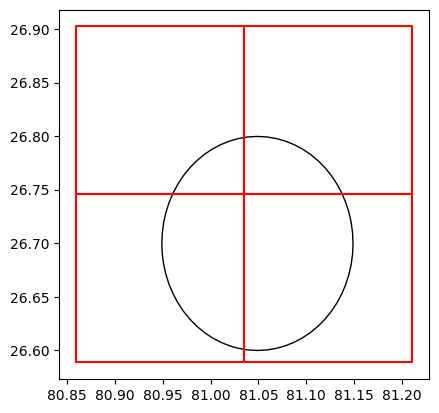

In [64]:
shape_gdf.plot(color="none", edgecolor="black")
for quad in tqdm(quads):
    bounds = quad['bbox']
    plt.plot([bounds[0], bounds[2], bounds[2], bounds[0], bounds[0]], [bounds[1], bounds[1], bounds[3], bounds[3], bounds[1]], color="red")

In [65]:
bboxes = np.array([quad['bbox'] for quad in quads])
print(f"{bboxes.shape=}")

top_left_inside = vectorized.contains(shape_gdf.geometry.item(), bboxes[:, 0], bboxes[:, 3])
top_right_inside = vectorized.contains(shape_gdf.geometry.item(), bboxes[:, 2], bboxes[:, 3])
bottom_left_inside = vectorized.contains(shape_gdf.geometry.item(), bboxes[:, 0], bboxes[:, 1])
bottom_right_inside = vectorized.contains(shape_gdf.geometry.item(), bboxes[:, 2], bboxes[:, 1])
one_of_the_corners_inside = np.logical_or(np.logical_or(top_left_inside, top_right_inside), np.logical_or(bottom_left_inside, bottom_right_inside))
print(f"{one_of_the_corners_inside.sum()=}")

bboxes.shape=(4, 4)
one_of_the_corners_inside.sum()=4


In [66]:
quads_within_roi = np.array(quads)[one_of_the_corners_inside]
quads_within_roi.shape

(4,)

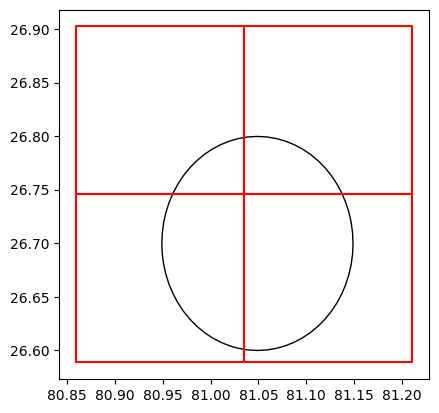

In [67]:
shape_gdf.plot(color="none", edgecolor="black")
for quad in quads_within_roi:
    bounds = quad['bbox']
    plt.plot([bounds[0], bounds[2], bounds[2], bounds[0], bounds[0]], [bounds[1], bounds[1], bounds[3], bounds[3], bounds[1]], color="red")

In [68]:
# each item in quads_within_roi is a dict. Combine into a geojson feature collection
features = []
for quad in tqdm(quads_within_roi):
    feature = {
        "type": "Feature",
        "geometry": {
            "type": "Polygon",
            "coordinates": [[
                [quad['bbox'][0], quad['bbox'][1]],
                [quad['bbox'][2], quad['bbox'][1]],
                [quad['bbox'][2], quad['bbox'][3]],
                [quad['bbox'][0], quad['bbox'][3]],
                [quad['bbox'][0], quad['bbox'][1]],
            ]],
        },
        "properties": {
            "_self": quad['_links']['_self'],
            "download": quad['_links']['download'],
            "items": quad['_links']['items'],
            "thumbnail": quad['_links']['thumbnail'],
            "id": quad['id'],
            "percent_covered": quad['percent_covered'],
        }
    }
    features.append(feature)
    
collection = geojson.FeatureCollection(features)

  0%|          | 0/4 [00:00<?, ?it/s]

In [69]:
os.makedirs(metadata_save_dir, exist_ok=True)
with open(join(metadata_save_dir, "metadata.geojson"), "w") as f:
    geojson.dump(collection, f)

In [70]:
with open(join(metadata_save_dir, "metadata.geojson"), "r") as f:
    collection = geojson.load(f)

In [71]:
features = collection['features']
print(f"{len(features) = }")
set([feature['properties']['percent_covered'] for feature in features])

len(features) = 4


{100}

In [72]:
print(features[0])

{"geometry": {"coordinates": [[[80.859375, 26.74561], [81.035156, 26.74561], [81.035156, 26.902477], [80.859375, 26.902477], [80.859375, 26.74561]]], "type": "Polygon"}, "properties": {"_self": "https://api.planet.com/basemaps/v1/mosaics/a378ff71-e48b-4602-9993-bb2896a68ab3/quads/1484-1182?api_key=PLAKea85382c048b4ba086c40e3823d83d11", "download": "https://link.planet.com/basemaps/v1/mosaics/a378ff71-e48b-4602-9993-bb2896a68ab3/quads/1484-1182/full?api_key=PLAKea85382c048b4ba086c40e3823d83d11", "id": "1484-1182", "items": "https://api.planet.com/basemaps/v1/mosaics/a378ff71-e48b-4602-9993-bb2896a68ab3/quads/1484-1182/items?api_key=PLAKea85382c048b4ba086c40e3823d83d11", "percent_covered": 100, "thumbnail": "https://tiles.planet.com/basemaps/v1/planet-tiles/global_quarterly_2024q1_mosaic/gmap/11/1484/865.png?api_key=PLAKea85382c048b4ba086c40e3823d83d11"}, "type": "Feature"}


In [73]:
download_imagery_dir = join(download_dir, "imagery", mosaic['name'])
print(download_imagery_dir)
os.makedirs(download_imagery_dir, exist_ok=True)

../raw_data/imagery/global_quarterly_2024q1_mosaic


In [74]:


def download_feature(feature):
    file_id = feature['properties']['id']
    file_path = join(download_imagery_dir, f"{file_id}.tif")
    
    download_url = feature['properties']['download']
    if exists(file_path):
        try:
            image = Image.open(file_path)
            assert image.size == (4096, 4096)
            # print(f"File already exists: {file_path}.")
            return  # Skip if the file is already downloaded and is not corrupted
        except:
            print(f"Corrupted file: {file_path}.")

    response = requests.get(download_url, headers=headers)

    # print(f"{response.status_code=}")
    with open(file_path, "wb") as f:
        f.write(response.content)
        
    da = rxr.open_rasterio(file_path)
    # round x, y to 6 decimal places
    da = da.assign_coords(x=np.round(da.x, 6))
    da = da.assign_coords(y=np.round(da.y, 6))
    kwargs = {'blockxsize': 512, 'blockysize': 512, 'tiled': True, 'compress': 'lzw', 'interleave': 'band'}
    da.rio.to_raster(file_path, **kwargs)
    
    # reload for testing
    # reload_da = rxr.open_rasterio(file_path)
    # return reload_da

# test
# da = download_feature(features[0])
# da.x.values[0:5]
# _ = Parallel(n_jobs=48)(delayed(download_feature)(feature) for feature in tqdm(features))
with cf.ThreadPoolExecutor(max_workers=48) as executor:
    list(tqdm(executor.map(download_feature, features), total=len(features)))

  0%|          | 0/4 [00:00<?, ?it/s]

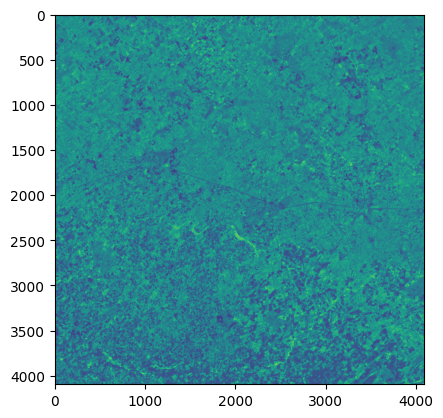

In [23]:
#visualize the downloaded images
import rasterio
import matplotlib.pyplot as plt
data=rasterio.open('../raw_data/imagery/global_quarterly_2024q1_mosaic/1433-1169.tif')
plt.imshow(data.read(1))

In [ ]:
corruptepetd_files = "../raw_data/imagery/global_quarterly_2024q1_mosaic/1531-1164.tif"
os.remove(corruptepetd_files)
print("Removed corrupted files")


Removed corrupted files
